# s00_monotone_intro
This notebook steps through some fundamental principles of the FFT and the Welch periodogram.

Although varations of these concepts can be found in other repositories, they are presented here for cohesiveness.

Please refer to scipy's spectral analysis documentation:   
https://docs.scipy.org/doc/scipy/tutorial/signal.html#spectral-analysis

## Introduction to Time-Frequency Representations (TFRs)

The foundation of efficient TFR computation is the Fast Fourier Transform (FFT), the computationally efficient implementation of the Discrete Fourier Transform (DFT). For a signal with $N$ samples the FFT reduces the computational cost from $O(N^2)$ to $O(N\log N)$. FFT algorithms are most efficient when $N$ is a power of two; in practice, short signals are often zero-padded to the next dyadic length (powers of two), which can introduce edge effects if not handled deliberately.

This first case study constructs a sinusoidal input with unit amplitude to validate that the average spectral power over the record equals $\tfrac{1}{2}$ when the tone frequency aligns exactly with an FFT bin.

Only NumPy is required for this example. If you expect physically calibrated (SI) outputs, verify the conventions used by each FFT routine and keep track of scaling factors (e.g. dividing by $N$) when converting between Fourier coefficients and power. Libraries evolve over time, so double-check function semantics when upgrading dependencies.

In [1]:
import numpy as np
print(f"NumPy version: {np.__version__}")

NumPy version: 2.3.1


### Monotone design

The snippet explains assumptions and practical constraints when working with discrete-time sinusoids and spectra.

An evenly sampled input is assumed, where the sample rate is a nominal constant measured in samples per second (sps or Hz). Even sampling is important because almost all frequency-domain analysis and synthesis formulas assume uniform spacing. If the acquisition clock "wobbles" or samples arrive irregularly, resampling or interpolation can be used to reconstruct a uniformly sampled signal before spectral processing.

The highest representable frequency in the digital domain is the Nyquist frequency, which is one half of the sample rate. This is expressed as $$f_N = \frac{f_s}{2}$$ and means all meaningful spectral content lies in $[0, f_N]$. Any energy above $f_N$ will fold back (alias) into this band and corrupt the measured spectrum.

To avoid aliasing, the analog front-end should include an anti-aliasing low-pass filter that attenuates signal power above the passband so that residual energy near Nyquist is negligible compared to noise. Designing that filter aggressively (steep transition, sufficient stopband attenuation) is a key practical requirement—otherwise a digitally generated or analyzed sinusoid may show spurious components caused by aliasing rather than the true signal.

This example constructs a trivial, extremely simple sinusoidal synthetic with a sample rate of $f_s=800\ \text{Hz}$, with a Nyquist frequency of $f_N=400\ \text{Hz}$. That defines the usable spectral canvas: frequencies of interest should be band-limited and filtered accordingly before sampling so that all energy is below 400 Hz. The continuous wave synthetic has a center frequency of 60 Hz, and all spectral energy will be concentrated well below Nyquist.

In [2]:
# Parameters and derived quantities
frequency_sample_rate_hz = 800.
frequency_center_hz = 60.
time_duration_s = 1  # Nominal value
# Use the whole record to compute the fft
time_fft_s = time_duration_s
frequency_resolution_hz = 1 / time_fft_s

# Since int() round down, this computes the closest highest lowest power of two (FFT-friendly).
time_duration_nd = 2 ** (int(np.log2(time_duration_s * frequency_sample_rate_hz)))
time_fft_nd = 2 ** (int(np.log2(time_fft_s * frequency_sample_rate_hz)))

This example overrides the 'nominal' physical specifications and computes the monotone synthetic using the dyadic (base 2) number of points. For a real (in contrast to imaginary) input signal, numpy fft.rfft computes only the one-sided positive frequencies out to Nyquist.

In [3]:
# Positive FFT frequencies and locate the closest FFT bin to the nominal center frequency
frequency_fft_pos_hz = np.fft.rfftfreq(time_fft_nd, d=1/frequency_sample_rate_hz)
fft_index = np.argmin(np.abs(frequency_fft_pos_hz - frequency_center_hz))
frequency_center_fft_hz = frequency_fft_pos_hz[fft_index]
frequency_resolution_fft_hz = frequency_sample_rate_hz / time_fft_nd

The spectral resolution is the inverse of the signal duration. If $T$ is the duration of the record, then the frequency spacing is:

$$\Delta f = \frac{1}{T}$$

When the record contains $N$ samples taken at sampling rate $f_s$, we have $T = N / f_s$ and therefore

$$\Delta f = \frac{f_s}{N}$$

A decrease in signal duration (smaller $N$) increases the spacing between adjacent frequency bins, so a pure tone may not fall exactly on a bin and its energy can spread across neighbouring bins (spectral leakage) or be underestimated.

In [4]:
# Print diagnostic information
print('Nyquist frequency:', frequency_sample_rate_hz / 2)
print('Nominal signal frequency, hz:', frequency_center_hz)
print('Closest FFT signal frequency, hz:', frequency_center_fft_hz)
print('Nominal spectral resolution, hz', frequency_resolution_hz)
print('FFT spectral resolution, hz', frequency_resolution_fft_hz)
print('Number of FFT points:', time_duration_nd)
print('log2(FFT points):', np.log2(time_duration_nd))

Nyquist frequency: 400.0
Nominal signal frequency, hz: 60.0
Closest FFT signal frequency, hz: 59.375
Nominal spectral resolution, hz 1.0
FFT spectral resolution, hz 1.5625
Number of FFT points: 512
log2(FFT points): 9.0


Algorithmically, it is convenient to work with nondimensional (normalized) time and frequency scaled by the sampling rate. Define the normalized frequency $\nu$ and the time sample index time_nd.
The normalized frequency for Nyquist lies in $\nu\in[0,\tfrac{1}{2}]$. Normalization lets you write sinusoids compactly (see next cell) and compare mathematical formulas directly with the code variables. Physical units can be reintroduced at the end if needed.

In [5]:
# Dimensionless conversions and time vector (samples)
frequency_center_fft = frequency_center_fft_hz / frequency_sample_rate_hz # From closest normalized fft frequency to nominal
time_nd = np.arange(time_duration_nd)

Construct the simplest sinusoid with oscillation frequency far from Nyquist so aliasing is negligible.

In [6]:
# Construct the synthetic tone (maximum FFT amplitude at exact FFT frequency closest to specified)
mic_sig = np.cos(2 * np.pi * frequency_center_fft * time_nd)

Note the different durations of fft.rfft and fft.fft

In [7]:
# Compute the RFFT of the whole record and compare to the full FFT
fft_sig_pos = np.fft.rfft(mic_sig)
fft_sig = np.fft.fft(mic_sig)
print('RFFT returns only the positive frequencies')
print('len(FFT):', len(fft_sig))
print('len(RFFT):', len(fft_sig_pos))
print('RFFT[fc]:', fft_sig_pos[fft_index])

RFFT returns only the positive frequencies
len(FFT): 512
len(RFFT): 257
RFFT[fc]: (256-3.03391770985856e-12j)


Compute the spectral power averaged over the signal duration from the know relations

In [8]:
# Scale and compute FFT power
fft_abs_pos_over_N = np.abs(fft_sig_pos) / len(mic_sig)
fft_abs_power = 2 * fft_abs_pos_over_N ** 2

### Check amplitudes

The nominal FFT peak and average amplitudes and power for a monotinic signal of unit amplitude with no DC offset, and with center frequency sufficiently far from the Nyquist are:   

Positive-frequency FFT magnitude:

$$\left|\frac{\mathrm{RFFT}(f_c)}{N}\right| = \frac{1}{2}$$

Negative-frequency FFT magnitude:

$$\left|\frac{\mathrm{RFFT}(-f_c)}{N}\right| = \frac{1}{2}$$

Power at the peak frequency:

$$P(f_c) = 2\left|\frac{\mathrm{RFFT}(f_c)}{N}\right|^{2} = \frac{1}{2}$$

Total power (sum over positiver bins):

$$\mathrm{Total\ power} = \sum_{k} P_{k} = \frac{1}{2}$$

RMS amplitude:

$$\mathrm{RMS} = \sqrt{P} = \frac{1}{\sqrt{2}}$$




In [9]:
print(f'|RFFT(fc)/N|: {fft_abs_pos_over_N[fft_index]}')
print(f'2 * |RFFT(fc)/N|**2: {fft_abs_power[fft_index]}')
print(f'Signal RMS amplitude: {np.sqrt(np.sum(fft_abs_power))}')

|RFFT(fc)/N|: 0.5
2 * |RFFT(fc)/N|**2: 0.5
Signal RMS amplitude: 0.7071067811865476



### Exact reconstruction only occurs when the FFT frequency matches the oscillation frequency! 
In this example, the oscillation frequency is far from Nyquist so there are no aliasing issues.

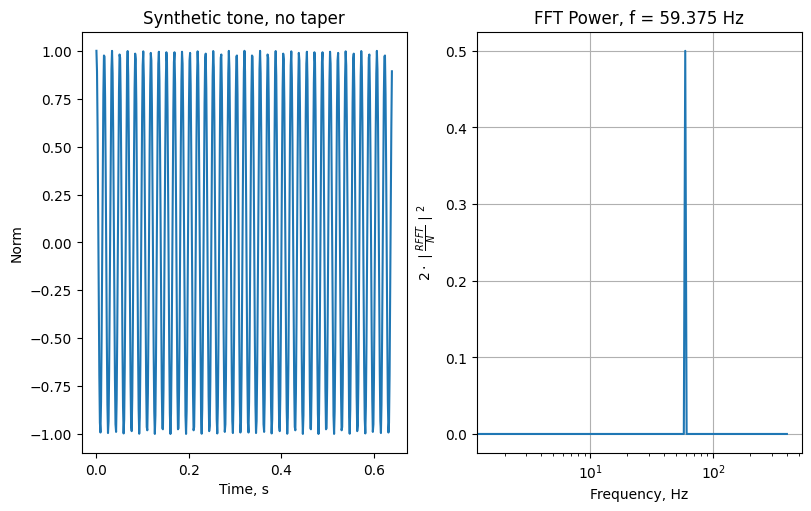

In [10]:
import matplotlib.pyplot as plt
# Plot waveform and FFT power
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(8, 5))
ax1.plot(time_nd / frequency_sample_rate_hz, mic_sig)
ax1.set_title('Synthetic tone, no taper')
ax1.set_xlabel('Time, s')
ax1.set_ylabel('Norm')
ax2.semilogx(frequency_fft_pos_hz, fft_abs_power)
ax2.set_title(f"FFT Power, f = {frequency_center_fft_hz:.3f} Hz")
ax2.set_xlabel('Frequency, Hz')
ax2.set_ylabel("$2\\cdot\\mid\\frac{RFFT}{N}\\mid ^2$")
ax2.grid(True)
plt.show()

## Parting Notes

- Introduced scaled time and frequency for FFT-based spectral analysis.
- Exact amplitue and power recovery occurs only when the sinusoid frequency aligns with an FFT bin.
- If you change `frequency_center_hz` to a non-bin frequency, the peak amplitude will spread across neighbouring bins (spectral leakage).